# 00 — Estrutura do pacote e fluxo completo

## Módulos e dependências

```text
NÚCLEO           distributions   samples
                        └──────┬──────┘
                             models ───────────────┐
                ┌──────────┬───┴─────┬─────────┐   │
            raster_io  separability validation fitting
DADOS       sampling   autocorrelation   masking
TRAJETÓRIAS transitions ──► cmap
                       └──► trajectory_assessment
APOIO       plots   diagnostics
```

Não há dependência circular: cada módulo só depende de módulos acima dele. Toda lógica específica de uma distribuição fica em `distributions.py`.

## Fluxo de processamento

| Etapa | Objetivo | Chamadas | Notebook |
|---|---|---|---|
| 0 | Máscara de nuvens | `masking.apply_mask` | 07 |
| 1 | Lags de descorrelação | `autocorrelation.sample_lags` → `summarize_lags` → `lags_for_sampling` | 06 |
| 2 | Desenho amostral | `sampling.lag_grid_split` (ou `raster_samples_to_points` + `random_split_points`) | 06 |
| 3 | Conjunto amostral | `sampling.extract_samples` → `df_samples` | 06 |
| 4 | Aderência e ENL | `fitting.iterative_gamma_fitting`, `fitting.normal_fitting_mv` | 05 |
| 5 | Separabilidade | `separability.bhattacharyya_matrix` → `hierarchical_clustering` → `extract_hierarchy` | 02 |
| 6 | Validação | `validation.cross_validation` → `reproduce_iteration` | 04 |
| 7 | Modelo e rasters por data | `models.fit_model` → `raster_io.likelihood_raster`, `raster_io.classification_raster` | 03 |
| 8 | CMAP | `transitions.create_transition_matrix_table` → `cmap.cmap_classifier` | 07 |
| 9 | Avaliação | `trajectory_assessment.impossible_trajectories`, `compare_classifications` | 07 |

## Correspondência com os códigos originais

| Script R / notebook original | Função | Python |
|---|---|---|
| 11 | `img2df`, `df2img` | `raster_io.raster_to_table`, `raster_io.table_to_raster` |
| 11 | `df_samples_creation`, `downsample_data`, `class_generalization`, `split_classes`, `split_samples` | `samples.*` |
| 11 | `parameters_estimation` (+ funções por distribuição) | `models.fit_model` → catálogo |
| 11 | `*_class_likelihood`, `maximum_likelihood_classifier` | `models.class_likelihood`, `models.classify` |
| 11 | Bhattacharyya, JM, `exhaustive_search_jm_optimal`, `extract_hierarchy` | `separability.*` |
| 11 | `plot_dendrogram`, `data_analysis`, `ball_graphs` | `plots.*` |
| 12 | `gamma_*`, `normal_*`, `iterative_gamma_fitting`, `best_ENL` | `fitting.*` |
| 13 | `cross_validation`, métricas, `aggregate_classes` | `validation.*` |
| 14 | `raster_to_shapefile_sample` | `sampling.raster_samples_to_points` + `sampling.random_split_points` |
| 14 | `raster_to_shapefile_sample_by_lags` | `sampling.lag_grid_split` |
| 14 | `divide_data` | `sampling.split_points` |
| SAMPLES_TO_POINTS | `raster_to_points` | `sampling.raster_samples_to_points` |
| correlation_2 | `autocorrelation`, `find_nearest` | `autocorrelation.autocorrelation_profiles`, `decorrelation_lag` |
| correlation_2 | `extrair_dados_raster`, laço principal | `autocorrelation.polygon_window`, `sample_lags` |
| correlation_2 | `calculate_iqr`, `find_max_lag_without_outliers`, `maiores_lags` | `autocorrelation.summarize_lags`, `lags_for_sampling` |
| correlation_2 | `bounding_box` | `sampling.polygon_envelopes` |
| cloud_masking | `masking_replace` | `masking.mask_array`, `masking.apply_mask` |
| CMAP_FUNCTIONS | `create_transition_matrix_table`, `cmap_classifier` | `transitions.create_transition_matrix_table`, `cmap.cmap_classifier` |
| CMAP_FUNCTIONS | `verify_rasters` | `raster_io.verify_rasters` |
| CMAP_FUNCTIONS | `plot_single_raster`, `plot_classification_results` | `plots.plot_single_raster`, `plots.plot_classification_results` |
| trajectory_assessment | `calcularTransicoesImpossiveis` | `trajectory_assessment.impossible_trajectories` |
| trajectory_assessment | `compareRasterClassification` | `trajectory_assessment.compare_classifications` |
| — (novo) | — | `sampling.extract_samples`, `raster_io.likelihood_raster`, `raster_io.classification_raster`, `models.save_model`, `validation.reproduce_iteration` |

In [1]:
import sys, tempfile
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))   # pasta que contém sar_classification

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.transform import from_origin
from sar_classification import (sampling, autocorrelation as ac, masking, transitions as trn, cmap,
                                trajectory_assessment as ta, models as mdl, raster_io as rio,
                                validation as val, fitting as fit, separability as sep, plots)

In [2]:
# ---------------------------------------------------------------------------------
# Cena fictícia: 4 classes em blocos, série de 3 datas (intensidade HH, Gama L = 4),
# textura espacial (speckle correlado), mudança de uma região entre as datas,
# raster de amostras (polígonos rasterizados) e máscara de nuvens.
# ---------------------------------------------------------------------------------
from scipy.ndimage import gaussian_filter
from shapely.geometry import box
import geopandas as gpd

rng = np.random.default_rng(2024)
WORK = Path(tempfile.mkdtemp())
H, W, RES = 120, 160, 12.5
TR = from_origin(300000, 7400000, RES, RES)
CRS = 'EPSG:31983'
classes = ['F', 'VS', 'PA', 'SE']
mu = {'F': 0.08, 'VS': 0.055, 'PA': 0.025, 'SE': 0.012}

truth0 = np.repeat(np.arange(4), W // 4)[None, :].repeat(H, axis=0)
truths = [truth0.copy(), truth0.copy(), truth0.copy()]
truths[1][:40, 40:80] = 2                       # VS -> PA (desmatamento) a partir da data 2
truths[2][:40, 40:80] = 2

def write(path, arr, dtype, nodata=None, desc=None):
    arr = arr if arr.ndim == 3 else arr[None]
    with rasterio.open(path, 'w', driver='GTiff', height=H, width=W, count=arr.shape[0], dtype=dtype,
                       crs=CRS, transform=TR, nodata=nodata) as dst:
        dst.write(arr.astype(dtype))
        for i, n in enumerate(desc or []):
            dst.set_band_description(i + 1, n)
    return path

images = []
for t, truth in enumerate(truths):
    tex = gaussian_filter(rng.normal(size=(H, W)), 2.0); tex = np.exp(0.6 * tex / tex.std())
    mean = np.array([mu[c] for c in classes])[truth] * tex
    images.append(write(WORK / f'HH_{2005 + t}.tif', rng.gamma(4.0, mean / 4.0), 'float32', desc=['HH']))

cloud = np.zeros((H, W), np.uint8); cloud[90:110, 100:140] = 1
write(WORK / 'nuvens.tif', cloud, 'uint8')

# polígonos de amostra (retângulos) e raster de amostras (códigos 1..4; 0 = fundo)
polys, labels, sample_r = [], [], np.zeros((H, W), np.int16)
for k, c in enumerate(classes):
    for _ in range(6):
        r0, c0 = rng.integers(45, H - 22), rng.integers(k * 40 + 1, k * 40 + 19)
        sample_r[r0:r0 + 20, c0:c0 + 20] = k + 1
        x0, y0 = TR * (c0, r0 + 20); x1, y1 = TR * (c0 + 20, r0)
        polys.append(box(x0, y0, x1, y1)); labels.append(c)
write(WORK / 'amostras_2005.tif', sample_r, 'int16', nodata=0)
polygons = gpd.GeoDataFrame({'Classe': labels}, geometry=polys, crs=CRS)
print('Arquivos fictícios em', WORK)

Arquivos fictícios em /tmp/tmpo0o1_tlu


## Etapa 0 — Máscara de nuvens

Aplicada em cada imagem antes da extração. Os pixels mascarados viram nodata e saem automaticamente de amostras, verossimilhanças e classificações.

In [3]:
masked = [masking.apply_mask(p, WORK / 'nuvens.tif', str(p).replace('.tif', '_mask.tif'), value=np.nan)
          for p in images]

800 pixels mascarados em 1 banda(s) -> /tmp/tmpo0o1_tlu/HH_2005_mask.tif
800 pixels mascarados em 1 banda(s) -> /tmp/tmpo0o1_tlu/HH_2006_mask.tif
800 pixels mascarados em 1 banda(s) -> /tmp/tmpo0o1_tlu/HH_2007_mask.tif


## Etapas 1 a 3 — Lags, desenho amostral e conjunto amostral

In [4]:
lags_poly = ac.sample_lags(masked[0], polygons, 'Classe', target_correlation=0.3, verbose=False)
lags = ac.lags_for_sampling(ac.summarize_lags(lags_poly))
print('Lags por classe:'); print(lags.T)

train_pts, valid_pts = sampling.lag_grid_split(WORK / 'amostras_2005.tif', classes, lags)
df_samples = {Path(p).stem[3:7]: sampling.extract_samples(train_pts, p) for p in masked}
print('\nAmostras de treino por classe:', df_samples['2005']['Class'].value_counts().to_dict())

Lags por classe:
class  F  PA  SE  VS
h      3   6   5   3
v      3   3   4   3
extract_samples: 33 pontos sem valor válido na imagem foram descartados.
extract_samples: 33 pontos sem valor válido na imagem foram descartados.
extract_samples: 33 pontos sem valor válido na imagem foram descartados.

Amostras de treino por classe: {'VS': 181, 'F': 130, 'PA': 66, 'SE': 41}


## Etapas 4 a 6 — ENL, separabilidade e validação

In [5]:
ENL = fit.iterative_gamma_fitting(df_samples['2005'], classes, verbose=False)['best_enl']
print(f'ENL = {ENL:.3f}')
B = sep.bhattacharyya_matrix(df_samples['2005'], classes, 'gamma', ENL)
print(sep.extract_hierarchy(sep.hierarchical_clustering(B), classes))
cv = val.cross_validation(df_samples['2005'], classes, 'gamma', ENL, n_iterations=20, verbose=False)
print(val.cross_validation_stats(cv)['Overall_Stats'].round(4).to_string(index=False))

ENL = 1.697


{'lvl_1': ['F', 'VS'], 'lvl_2': ['PA', 'SE'], 'lvl_3': ['F', 'VS', 'PA', 'SE']}


  Mean     SD  ci_lw  ci_up
0.4799 0.0337  0.425 0.5347


## Etapa 7 — Modelo e rasters por data

Uma codificação de classes única (`codes`) é usada no MaxVer e no CMAP, o que permite a comparação pixel a pixel na etapa 9.

In [6]:
codes = cmap.default_class_codes(classes)
lik_paths, ml_paths = [], []
for year, p in zip(df_samples, masked):
    model = mdl.fit_model(df_samples[year], classes, 'gamma', ENL)
    lik_paths.append(rio.likelihood_raster(p, model, WORK / f'lik_{year}.tif'))
    ml_paths.append(rio.classification_raster(p, model, WORK / f'MaxVer_{year}.tif', class_codes=codes)['raster'])
print('Códigos:', codes)

Códigos: {'F': 1, 'PA': 2, 'SE': 3, 'VS': 4}


## Etapa 8 — CMAP

Matriz de validade fictícia: todas as classes podem permanecer; VS → PA é permitida; as demais mudanças são impossíveis.

In [7]:
valid = pd.DataFrame(np.eye(4), index=classes, columns=classes); valid.loc['VS', 'PA'] = 1
for name in ('2005-2006', '2006-2007'):
    valid.to_csv(WORK / f'{name}.txt', sep=';')
trajectories = trn.create_transition_matrix_table([WORK / '2005-2006.txt', WORK / '2006-2007.txt'])
out = cmap.cmap_classifier(lik_paths, trajectories, output_dir=WORK / 'cmap', date_labels=['2005', '2006', '2007'],
                           class_codes=codes, verbose=False)

Aviso: em '2005-2006.txt', 1 linha(s) não somam 1 (Eq. 2.13) — esperado apenas em matriz de validade.
Aviso: em '2006-2007.txt', 1 linha(s) não somam 1 (Eq. 2.13) — esperado apenas em matriz de validade.
Trajetórias: 64 | P(s) > 0: 6 | inválidas: 58 | P(ω1) uniforme


## Etapa 9 — Avaliação

In [8]:
legend = {v: k for k, v in codes.items()}
mats = [trn.read_transition_matrix(WORK / f'{n}.txt', verbose=False) for n in ('2005-2006', '2006-2007')]
imp_ml = ta.impossible_trajectories(ml_paths, mats, legends=legend)
imp_cmap = ta.impossible_trajectories(out['classified'], mats, legends=legend)
print(f"Trajetórias impossíveis — MaxVer: {imp_ml['percentage']:.2f}% | CMAP: {imp_cmap['percentage']:.2f}%\n")
cmp = ta.compare_classifications(ml_paths, out['classified'], WORK / 'nuvens.tif', legend, legend,
                                 date_labels=['2005', '2006', '2007'])

Trajetórias impossíveis — MaxVer: 77.60% | CMAP: 0.00%



date  n_valid  n_disagree  percentage
2005    18400        7390      40.163
2006    18400        7231      39.299
2007    18400        8064      43.826
Discordância total (>= 1 data): 77.603%


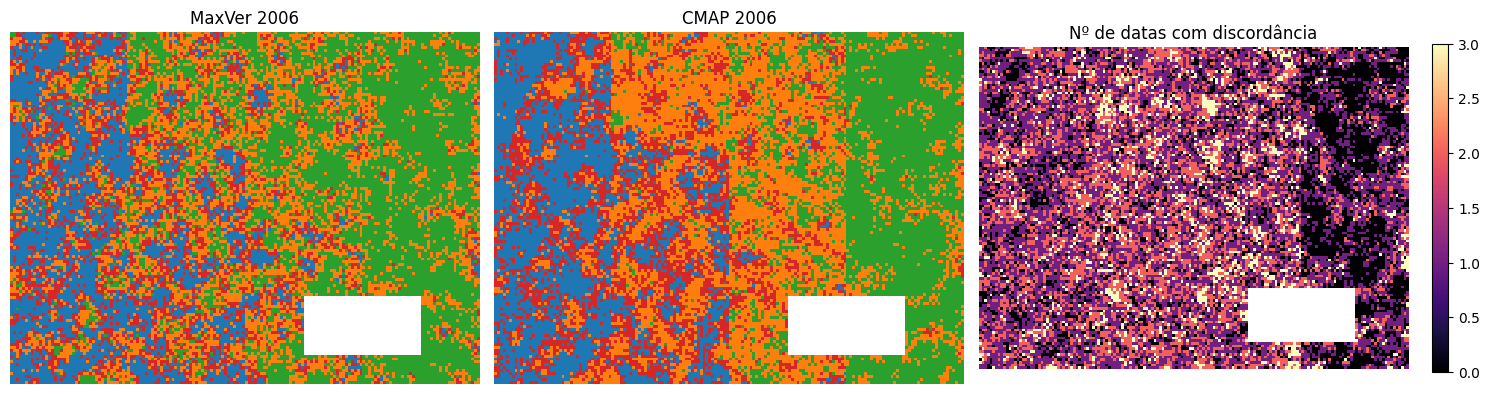

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (title, path) in zip(axes, [('MaxVer 2006', ml_paths[1]), ('CMAP 2006', out['classified'][1])]):
    with rasterio.open(path) as s:
        ax.imshow(np.ma.masked_equal(s.read(1), 0), cmap='tab10', vmin=1, vmax=10, interpolation='nearest')
    ax.set_title(title); ax.axis('off')
acc = np.ma.masked_less(cmp['accumulated'], 0)
im = axes[2].imshow(acc, cmap='magma', interpolation='nearest'); axes[2].set_title('Nº de datas com discordância'); axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.035)
plt.tight_layout(); plt.show()